<a href="https://colab.research.google.com/github/aditiital/Digital-image-processing-Lab/blob/main/practical9_DIP.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Area: 8403.00
Perimeter: 595.59
----------------
Area: 3250.00
Perimeter: 457.85
----------------
Area: 823.50
Perimeter: 116.53
----------------
Area: 5990.50
Perimeter: 580.63
----------------
Area: 598.00
Perimeter: 160.08
----------------
Area: 174284.00
Perimeter: 6443.27
----------------
Area: 6585.50
Perimeter: 851.26
----------------


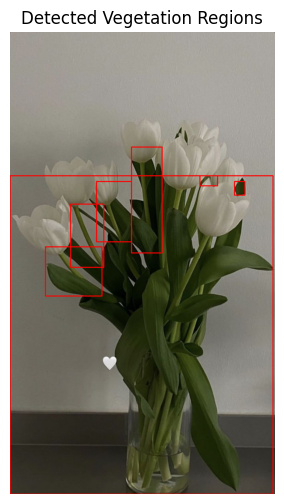

In [6]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
# Read image
img = cv2.imread("/content/tulip.jpg")
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
# Convert to HSV
hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)
# Green vegetation mask
lower_green = np.array([25, 40, 40])
upper_green = np.array([95, 255, 255])
mask = cv2.inRange(hsv, lower_green, upper_green)
# Remove noise
kernel = np.ones((5,5), np.uint8)
mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, kernel)
mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel)

# Find contours
contours, _ = cv2.findContours(
mask,
cv2.RETR_EXTERNAL,
cv2.CHAIN_APPROX_SIMPLE
)
output = img_rgb.copy()
for cnt in contours:
  area = cv2.contourArea(cnt)
  # Ignore tiny regions
  if area < 500:
    continue
  perimeter = cv2.arcLength(cnt, True)
  x, y, w, h = cv2.boundingRect(cnt)
  cv2.rectangle(output, (x,y), (x+w,y+h), (255,0,0), 2)
  print(f"Area: {area:.2f}")
  print(f"Perimeter: {perimeter:.2f}")
  print("----------------")
plt.figure(figsize=(10,6))
plt.imshow(output)
plt.title("Detected Vegetation Regions")
plt.axis("off")
plt.show()